In [1]:
from pipeline import build_features, generate_arabic_recommendation

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest


In [3]:
# data=pd.read_csv('smart_expense_final22222.csv')
data=pd.read_csv('smart_expense_three_segments.csv')

In [4]:
data.columns

Index(['user_id', 'date', 'salary', 'food', 'drink', 'shopping',
       'transportation', 'bills', 'health', 'entertainment', 'payment_method',
       'spend'],
      dtype='object')

In [5]:
data.shape

(73200, 12)

In [6]:
data.groupby(['user_id','date'])['salary'].count().max()

np.int64(1)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73200 entries, 0 to 73199
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         73200 non-null  int64  
 1   date            73200 non-null  object 
 2   salary          73200 non-null  int64  
 3   food            73200 non-null  float64
 4   drink           73200 non-null  float64
 5   shopping        73200 non-null  float64
 6   transportation  73200 non-null  float64
 7   bills           73200 non-null  float64
 8   health          73200 non-null  float64
 9   entertainment   73200 non-null  float64
 10  payment_method  73200 non-null  object 
 11  spend           73200 non-null  float64
dtypes: float64(8), int64(2), object(2)
memory usage: 6.7+ MB


In [8]:
data.describe()

,user_id,salary,food,drink,shopping,transportation,bills,health,entertainment,spend
count,73200.0000,73200.000000,73200.000000,73200.000000,73200.000000,73200.000000,73200.000000,73200.000000,73200.000000,73200.000000
mean,100.5000,19920.830000,100.857417,31.811420,85.625480,60.624289,91.399654,45.417726,45.426182,461.162168
std,57.7347,6319.725968,48.187912,16.164017,43.879375,29.878779,42.480148,23.282985,23.307947,189.750761
min,1.0000,8110.000000,12.893604,0.099374,0.504482,0.522894,13.480299,0.218336,0.265397,76.488074
25%,50.7500,14540.500000,63.769114,20.516264,52.949425,37.112657,57.651080,27.289277,27.273079,308.456689
50%,100.5000,20642.500000,94.194960,29.474300,77.402361,55.454909,84.161449,41.306083,41.307106,440.524877
75%,150.2500,25435.250000,129.400638,40.414341,110.890124,80.477875,118.581208,60.198299,60.295983,595.352622
max,200.0000,29695.000000,319.123414,119.215435,354.653641,230.231571,284.027115,178.173007,173.466627,1145.565883


In [9]:
data['user_id'].nunique()

200

In [10]:
data.isna().sum()

user_id           0
date              0
salary            0
food              0
drink             0
shopping          0
transportation    0
bills             0
health            0
entertainment     0
payment_method    0
spend             0
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data['date'] = pd.to_datetime(data['date'])

data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['weekday'] = data['date'].dt.weekday
data['is_weekend'] = data['weekday'].isin([5, 6]).astype(int)

In [13]:
data

,user_id,date,salary,food,drink,shopping,transportation,bills,health,entertainment,payment_method,spend,year,month,weekday,is_weekend
0,1,2024-01-01,23795,144.145857,66.185800,140.740685,72.479603,164.900033,49.874555,67.858452,Credit Card,706.184986,2024,1,0,0
1,1,2024-01-02,23795,117.071823,60.604120,96.000082,104.872705,142.649999,109.419640,77.866787,Cash,708.485155,2024,1,1,0
2,1,2024-01-03,23795,122.782090,56.483848,125.569620,113.381676,131.702602,66.217602,52.208466,Cash,668.345904,2024,1,2,0
3,1,2024-01-04,23795,116.789123,49.413416,145.709365,99.294460,168.156298,65.849628,74.299224,Debit Card,719.511515,2024,1,3,0
4,1,2024-01-05,23795,130.724804,58.169742,134.462981,118.091471,153.596065,81.639554,49.145384,Cash,725.830001,2024,1,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73195,200,2024-12-27,25497,69.536930,24.628032,53.998786,25.946091,47.660981,18.294626,12.500301,Credit Card,252.565746,2024,12,4,0
73196,200,2024-12-28,25497,140.614694,49.667434,105.174964,48.013453,103.440821,24.099369,27.340599,Debit Card,498.351334,2024,12,5,1
73197,200,2024-12-29,25497,138.357014,54.534751,101.375098,52.459323,72.660025,12.114368,28.481174,Cash,459.981754,2024,12,6,1
73198,200,2024-12-30,25497,125.134057,41.054541,81.270353,24.500305,75.061267,26.996263,32.403976,Credit Card,406.420762,2024,12,0,0


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73200 entries, 0 to 73199
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         73200 non-null  int64         
 1   date            73200 non-null  datetime64[ns]
 2   salary          73200 non-null  int64         
 3   food            73200 non-null  float64       
 4   drink           73200 non-null  float64       
 5   shopping        73200 non-null  float64       
 6   transportation  73200 non-null  float64       
 7   bills           73200 non-null  float64       
 8   health          73200 non-null  float64       
 9   entertainment   73200 non-null  float64       
 10  payment_method  73200 non-null  object        
 11  spend           73200 non-null  float64       
 12  year            73200 non-null  int32         
 13  month           73200 non-null  int32         
 14  weekday         73200 non-null  int32         
 15  is

In [15]:
# الصرف علي الشهور  
# عشان اعرف انهي شهر الصرف فيه اكتر وهل المصروفات بتزيد مع الوقت ولا لا 
data.groupby('month')['spend'].mean()

month
1     460.757321
2     460.420343
3     461.864009
4     460.335667
5     461.267805
6     461.563960
7     461.684888
8     459.342462
9     461.102499
10    463.071939
11    462.132698
12    460.370245
Name: spend, dtype: float64

In [16]:
# متوسط الصر بتاع كل user في الشهر 
monthly_user = data.groupby(['user_id','month'])['spend'].mean()
monthly_user

user_id  month
1        1        734.175242
         2        737.901422
         3        738.224111
         4        833.747104
         5        732.489195
                     ...    
200      8        434.306943
         9        439.944180
         10       457.011972
         11       431.769815
         12       430.368043
Name: spend, Length: 2400, dtype: float64

In [17]:
# هل في أي قيم سالبة في أي category؟
negative_counts = (data[['food','drink','shopping',
                       'transportation','bills',
                       'health','entertainment']] < 0).sum()

print(negative_counts)

food              0
drink             0
shopping          0
transportation    0
bills             0
health            0
entertainment     0
dtype: int64


In [18]:
# عشان افهم السلوك المستخدم يعتمد علي اي اكتر 
data['payment_method'].value_counts()

payment_method
Cash           32756
Credit Card    25732
Debit Card     14712
Name: count, dtype: int64

In [19]:
# هدفه يتأكد ان العمود spend = مجموع المصروفات في كل الفئات 
data['categories_sum'] = data[['food','drink','shopping',
                                'transportation','bills',
                                'health','entertainment']].sum(axis=1)

(data['spend'] - data['categories_sum']).abs().max()

np.float64(4.547473508864641e-13)

In [20]:
# عدّل عمود spend وخلاه يساوي مجموع المصروفات في كل الفئات لكل صف.
data['spend'] = data[['food','drink','shopping',
                      'transportation','bills',
                      'health','entertainment']].sum(axis=1)

In [21]:
(data['spend'] - data[['food','drink','shopping',
                       'transportation','bills',
                       'health','entertainment']].sum(axis=1)).abs().max()

np.float64(0.0)

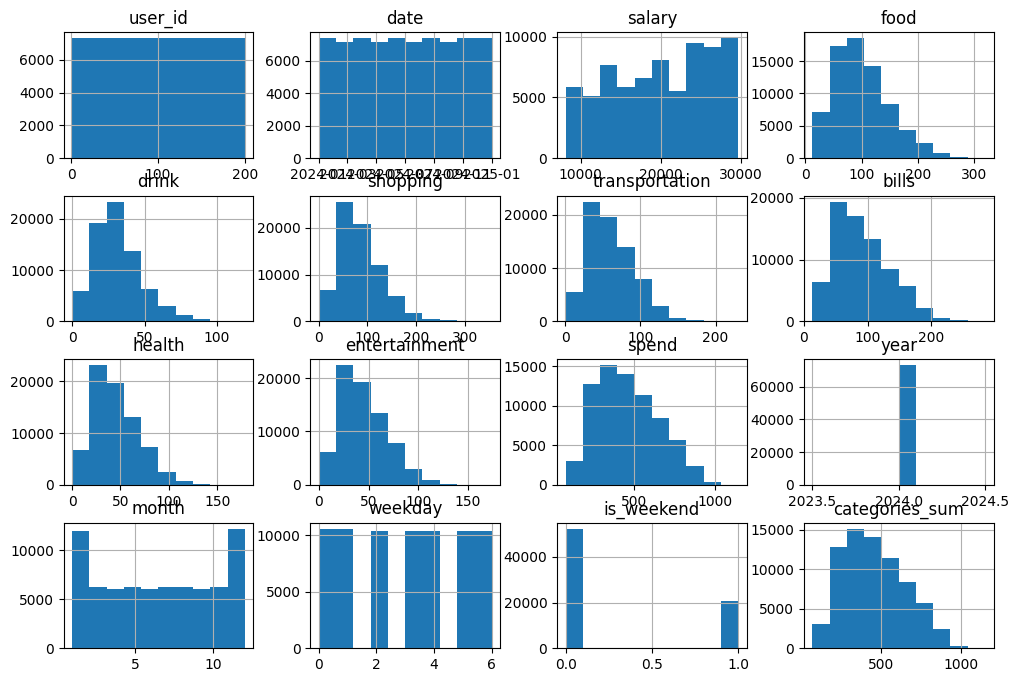

In [22]:
data.hist(figsize=(12,8))
plt.show()

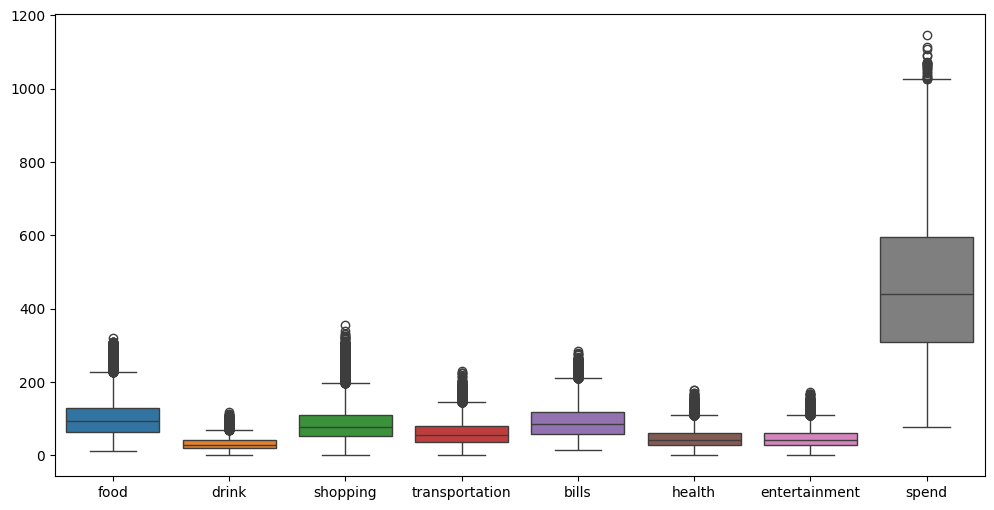

In [23]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data[['food','drink','shopping','transportation','bills','health','entertainment','spend']])
plt.show()

## feature Engineering 

In [24]:
df=data.copy()

## monhly aggregation 

In [25]:

monthly = (
    df.assign(year=df['date'].dt.year, month=df['date'].dt.month)
    .groupby(['user_id', 'year', 'month'], as_index=False)
    .agg(
        monthly_salary=('salary', 'first'),
        total_spend=('spend', 'sum'),
        total_food=('food', 'sum'),
        total_drink=('drink', 'sum'),
        total_shopping=('shopping', 'sum'),
        total_transport=('transportation', 'sum'),
        total_bills=('bills', 'sum'),
        total_health=('health', 'sum'),
        total_entertainment=('entertainment', 'sum'),
        days_in_month=('date', 'nunique'),
        max_daily_spend=('spend', 'max')
    )
)

# ─────────────────────────────
# نسبة الفئة للمرتب (ده الصح)
# ─────────────────────────────
for col in ['food', 'drink', 'shopping', 'transport', 'bills', 'health', 'entertainment']:
    monthly[f'{col}_pct_salary'] = (
        monthly[f'total_{col}'] / monthly['monthly_salary'].replace(0, np.nan)
    )

# نسبة إجمالي الصرف للمرتب (مهم للكلاستر)
monthly['spend_ratio'] = (
    monthly['total_spend'] / monthly['monthly_salary'].replace(0, np.nan)
)

monthly['remaining_salary'] = (
    monthly['monthly_salary'] - monthly['total_spend']
)

# تنظيف
salary_pct_cols = [c for c in monthly if c.endswith('_pct_salary')]
monthly[salary_pct_cols] = monthly[salary_pct_cols].fillna(0)

monthly['spend_ratio'] = monthly['spend_ratio'].replace([np.inf, -np.inf], np.nan)

print("Monthly Dataset Ready ✔")
print(monthly.head())

Monthly Dataset Ready ✔
   user_id  year  month  monthly_salary   total_spend   total_food  \
0        1  2024      1           23795  22759.432497  4021.195284   
1        1  2024      2           23795  21399.141251  3747.618420   
2        1  2024      3           23795  22884.947440  4075.633572   
3        1  2024      4           23795  25012.413115  4496.652137   
4        1  2024      5           23795  22707.165055  4053.957162   

   total_drink  total_shopping  total_transport  total_bills  ...  \
0  2035.773747     4328.852819      3105.559134  4772.708323  ...   
1  1998.240063     4099.658973      2816.177109  4449.142548  ...   
2  2066.078279     4577.310175      2998.846831  4752.590039  ...   
3  2210.528606     5144.046313      3337.871093  5115.774728  ...   
4  2050.331731     4540.356409      3127.024953  4509.660939  ...   

   max_daily_spend  food_pct_salary  drink_pct_salary  shopping_pct_salary  \
0       850.076635         0.168993          0.085555         

## user_level_aggregation

In [26]:
user_level = (
    monthly
    .groupby('user_id', as_index=False)
    .agg(
        # سلوك عام للكلاستر
        avg_spend_ratio        = ('spend_ratio', 'mean'),
        std_spend_ratio        = ('spend_ratio', 'std'),
        avg_remaining_salary   = ('remaining_salary', 'mean'),
        
        months_over_spending   = ('remaining_salary', lambda x: (x < 0).sum()),
        avg_monthly_spend      = ('total_spend', 'mean'),
        
        # 🔥 متوسط الفئات بالنسبة للمرتب (مش إجمالي الصرف)
        avg_food_pct_salary           = ('food_pct_salary', 'mean'),
        avg_drink_pct_salary          = ('drink_pct_salary', 'mean'),
        avg_shopping_pct_salary       = ('shopping_pct_salary', 'mean'),
        avg_transport_pct_salary      = ('transport_pct_salary', 'mean'),
        avg_bills_pct_salary          = ('bills_pct_salary', 'mean'),
        avg_health_pct_salary         = ('health_pct_salary', 'mean'),
        avg_entertainment_pct_salary  = ('entertainment_pct_salary', 'mean')
    )
)

# معالجة الانحراف المعياري
user_level['std_spend_ratio'] = user_level['std_spend_ratio'].fillna(0)

# تنظيف عام
user_level.replace([np.inf, -np.inf], np.nan, inplace=True)
user_level.fillna(0, inplace=True)

print("User-Level Dataset Ready ✔")
print(f"عدد المستخدمين: {len(user_level)}")
print(user_level.head())

User-Level Dataset Ready ✔
عدد المستخدمين: 200
   user_id  avg_spend_ratio  std_spend_ratio  avg_remaining_salary  \
0        1         0.959062         0.046613            974.115383   
1        2         0.697840         0.018035           2835.470256   
2        3         0.605120         0.018319          10489.195334   
3        4         0.908663         0.035422           1731.750704   
4        5         0.511010         0.014140           8361.242952   

   months_over_spending  avg_monthly_spend  avg_food_pct_salary  \
0                     2       22820.884617             0.169850   
1                     0        6548.529744             0.120273   
2                     0       16073.804666             0.120504   
3                     1       17228.249296             0.177735   
4                     0        8737.757048             0.118926   

   avg_drink_pct_salary  avg_shopping_pct_salary  avg_transport_pct_salary  \
0              0.086581                 0.187792   

## scailing 

In [27]:
selected_features = [
    'avg_spend_ratio',
    'std_spend_ratio',
    'months_over_spending',
    'avg_food_pct_salary',
    'avg_shopping_pct_salary',
    
    

]
X_features = user_level[selected_features].copy()
X_features.fillna(0, inplace=True)

In [28]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_features)

## KMeans

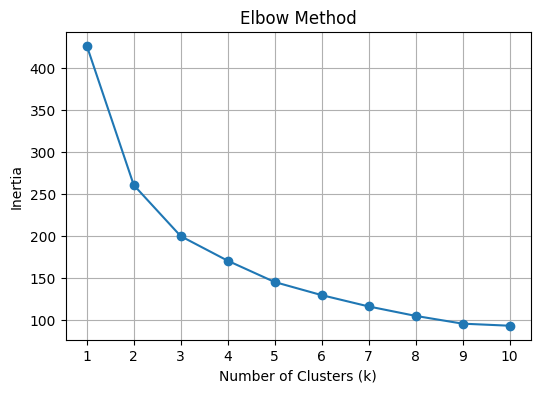

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)   # fit هنا بس لحساب inertia
    inertia.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [30]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
user_level['cluster'] = kmeans.fit_predict(X_scaled)

In [31]:
# كنت عامل 3 clusters  
# بس 2 طلع احسن بس برضو النسبه قليله اوي 
# cluster_means = (
#     user_level
#     .groupby('cluster')['avg_spend_ratio']
#     .mean()
#     .sort_values()
# )

# mapping = {
#     cluster_means.index[0]: 'Low',
#     cluster_means.index[1]: 'Medium',
#     cluster_means.index[2]: 'High'
# }

# user_level['spending_level'] = user_level['cluster'].map(mapping)
# print(cluster_means)

In [32]:
# print(
#     user_level
#     .groupby('spending_level')[
#         ['avg_spend_ratio',
#          'months_over_spending',
#          'std_spend_ratio']
#     ]
#     .mean()
# )

In [33]:
from sklearn.metrics import silhouette_score

# لو عندك X_scaled بالفعل
score = silhouette_score(X_scaled, kmeans.labels_)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.3335


In [34]:
user_level.groupby('cluster')[selected_features].mean()

,avg_spend_ratio,std_spend_ratio,months_over_spending,avg_food_pct_salary,avg_shopping_pct_salary
cluster,,,,,
0,0.600809,0.020062,0.000000,0.126900,0.105912
1,0.816477,0.031705,0.168421,0.181506,0.157344


In [35]:
user_level['cluster'].value_counts()

cluster
0    105
1     95
Name: count, dtype: int64

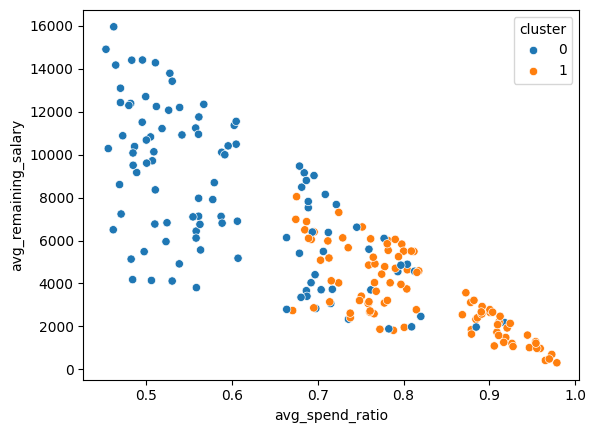

In [36]:
sns.scatterplot(
    x='avg_spend_ratio',
    y='avg_remaining_salary',
    hue='cluster',
    data=user_level
)
plt.show()

## recommendation Logic

In [37]:
categories = [
    'avg_food_pct_salary',
    'avg_drink_pct_salary',
    'avg_shopping_pct_salary',
    'avg_transport_pct_salary',
    'avg_bills_pct_salary',
    'avg_health_pct_salary',
    'avg_entertainment_pct_salary'
]
cluster_baseline = user_level.groupby('cluster')[categories].mean()

print(cluster_baseline)

         avg_food_pct_salary  avg_drink_pct_salary  avg_shopping_pct_salary  \
cluster                                                                       
0                   0.126900              0.043670                 0.105912   
1                   0.181506              0.054541                 0.157344   

         avg_transport_pct_salary  avg_bills_pct_salary  \
cluster                                                   
0                        0.083575              0.115542   
1                        0.102698              0.166425   

         avg_health_pct_salary  avg_entertainment_pct_salary  
cluster                                                       
0                     0.062596                      0.062613  
1                     0.077015                      0.076947  


In [46]:
import random

def generate_final_recommendation(row, baseline_mean_df, threshold=0.05):

    categories_info = {
        'avg_food_pct_salary': {
            "name": "الطعام",
            "advices": [
                "حاول تطبخ في البيت أكتر 🍳.",
                "قلل الأكل الجاهز شوية.",
                "راجع طلبات المطاعم."
            ]
        },
        'avg_drink_pct_salary': {
            "name": "المشروبات",
            "advices": [
                "قلل المشروبات الجاهزة 🥤.",
                "راجع مصاريف الكافيهات."
            ]
        },
        'avg_shopping_pct_salary': {
            "name": "التسوق",
            "advices": [
                "أجل المشتريات غير الضرورية 🛍️.",
                "اشتري حسب الحاجة بس."
            ]
        },
        'avg_transport_pct_salary': {
            "name": "المواصلات",
            "advices": [
                "جرب وسائل أوفر 🚗.",
                "قلل التنقلات غير الضرورية."
            ]
        },
        'avg_bills_pct_salary': {
            "name": "الفواتير",
            "advices": [
                "راجع استهلاك الكهرباء 💡.",
                "تابع الفواتير الشهرية بدقة."
            ]
        },
        'avg_health_pct_salary': {
            "name": "الصحة",
            "advices": [
                "خطط للمصاريف الصحية مسبقًا 🏥.",
                "تأكد إن المصاريف ضرورية."
            ]
        },
        'avg_entertainment_pct_salary': {
            "name": "الترفيه",
            "advices": [
                "قلل الخروجات شوية 🎮.",
                "حدد ميزانية واضحة للترفيه."
            ]
        }
    }

    cluster_id = row['cluster']
    spend_ratio = row['avg_spend_ratio']
    ratio_pct = round(spend_ratio * 100)

    # توصيف عام للحالة المالية
    if spend_ratio < 0.5:
        level_msg = "وضعك المالي آمن جدًا 👏"
    elif spend_ratio < 0.75:
        level_msg = "وضعك مستقر 👍"
    elif spend_ratio < 1:
        level_msg = "قريب من الحد الأقصى الآمن ⚠️"
    else:
        overspend = round((spend_ratio - 1) * 100)
        level_msg = f"أنت بتتجاوز دخلك بنسبة {overspend}% 🚨"

    deviations = []

    for col, data in categories_info.items():
        current = row[col]
        baseline = baseline_mean_df.loc[cluster_id, col]

        if baseline == 0:
            continue

        relative_diff = (current - baseline) / baseline

        if relative_diff > threshold:
            percent = round(relative_diff * 100)
            deviations.append((data["name"], percent, data["advices"]))

    if not deviations:
        return f"إنفاقك يمثل {ratio_pct}% من مرتبك، و{level_msg}."

    # اختيار أعلى فئة
    name, percent, advices = max(deviations, key=lambda x: x[1])
    advice = random.choice(advices)

    return (
        f"إنفاقك يمثل {ratio_pct}% من مرتبك، و{level_msg}. "
        f"مصاريف {name} أعلى من الطبيعي بنسبة {percent}%. "
        f"{advice}"
    )

In [47]:
user_level['recommendation'] = user_level.apply(
    lambda row: generate_final_recommendation(row, cluster_baseline),
    axis=1
)

In [48]:
user_level[['cluster', 'recommendation']].head(10)

,cluster,recommendation
0,1,إنفاقك يمثل 96% من مرتبك، وقريب من الحد الأقصى...
1,0,إنفاقك يمثل 70% من مرتبك، ووضعك مستقر 👍. مصاري...
2,0,إنفاقك يمثل 61% من مرتبك، ووضعك مستقر 👍. مصاري...
3,1,إنفاقك يمثل 91% من مرتبك، وقريب من الحد الأقصى...
4,0,إنفاقك يمثل 51% من مرتبك، ووضعك مستقر 👍. مصاري...
5,1,إنفاقك يمثل 78% من مرتبك، وقريب من الحد الأقصى...
6,0,إنفاقك يمثل 71% من مرتبك، ووضعك مستقر 👍. مصاري...
7,0,إنفاقك يمثل 76% من مرتبك، وقريب من الحد الأقصى...
8,1,إنفاقك يمثل 79% من مرتبك، وقريب من الحد الأقصى...
9,1,إنفاقك يمثل 88% من مرتبك، وقريب من الحد الأقصى...


In [49]:
print(user_level.loc[1, 'recommendation'])

إنفاقك يمثل 70% من مرتبك، ووضعك مستقر 👍. مصاريف التسوق أعلى من الطبيعي بنسبة 39%. اشتري حسب الحاجة بس.


In [51]:
for i in range(5):
    print(user_level.loc[i, 'recommendation'])
    print("-"*60)

إنفاقك يمثل 96% من مرتبك، وقريب من الحد الأقصى الآمن ⚠️. مصاريف المشروبات أعلى من الطبيعي بنسبة 59%. راجع مصاريف الكافيهات.
------------------------------------------------------------
إنفاقك يمثل 70% من مرتبك، ووضعك مستقر 👍. مصاريف التسوق أعلى من الطبيعي بنسبة 39%. اشتري حسب الحاجة بس.
------------------------------------------------------------
إنفاقك يمثل 61% من مرتبك، ووضعك مستقر 👍. مصاريف المشروبات أعلى من الطبيعي بنسبة 38%. راجع مصاريف الكافيهات.
------------------------------------------------------------
إنفاقك يمثل 91% من مرتبك، وقريب من الحد الأقصى الآمن ⚠️. مصاريف المواصلات أعلى من الطبيعي بنسبة 42%. قلل التنقلات غير الضرورية.
------------------------------------------------------------
إنفاقك يمثل 51% من مرتبك، ووضعك مستقر 👍. مصاريف الفواتير أعلى من الطبيعي بنسبة 17%. راجع استهلاك الكهرباء 💡.
------------------------------------------------------------


In [45]:
test_row = user_level.iloc[10]
cluster = test_row['cluster']

for category in categories:
    user_value = test_row[category]
    baseline_value = cluster_baseline.loc[cluster, category]
    diff = (user_value - baseline_value) / baseline_value
    
    print(category, "→", round(diff * 100, 2), "%")

avg_food_pct_salary → 12.17 %
avg_drink_pct_salary → -22.58 %
avg_shopping_pct_salary → -31.67 %
avg_transport_pct_salary → 47.11 %
avg_bills_pct_salary → 17.48 %
avg_health_pct_salary → 46.69 %
avg_entertainment_pct_salary → 47.22 %


In [54]:
for col, percent in deviations:
    print(f"إنفاقك على {category_names[col]} أعلى من الطبيعي بنسبة {percent}%")

إنفاقك على الطعام أعلى من الطبيعي بنسبة 12%
إنفاقك على المواصلات أعلى من الطبيعي بنسبة 47%
إنفاقك على الفواتير أعلى من الطبيعي بنسبة 17%
إنفاقك على الصحة أعلى من الطبيعي بنسبة 47%
إنفاقك على الترفيه أعلى من الطبيعي بنسبة 47%


## Save Model

In [53]:
import joblib

joblib.dump(scaler, "robust_scaler.joblib")
joblib.dump(kmeans, "kmeans_model.joblib")
joblib.dump(cluster_baseline, "cluster_baseline.joblib")
joblib.dump(categories, "categories.joblib")

print("Models Saved Successfully ✔")

Models Saved Successfully ✔


In [ ]:
# print(X_features.columns)

## بجرب  نواتح streamlit 

In [ ]:
print(cluster_baseline_mean)

In [ ]:
print(cluster_baseline_mean.shape)

In [ ]:
print(cluster_baseline_mean.loc[0])

In [ ]:
print(cluster_baseline_mean.columns)

In [ ]:
print("user_level rows:", user_level.shape[0])
print("X_scaled rows:", X_scaled.shape[0])